# Creating a Simple sequential agentic system

In [2]:
# !pip install crewai==0.28.8 crewai_tools==0.1.6 langchain_community==0.0.29

In [7]:
from crewai import Agent, Task, Crew

In [8]:
!pip show crewai

Name: crewai
Version: 0.148.0
Summary: Cutting-edge framework for orchestrating role-playing, autonomous AI agents. By fostering collaborative intelligence, CrewAI empowers agents to work together seamlessly, tackling complex tasks.
Home-page: https://crewai.com
Author: 
Author-email: Joao Moura <joao@crewai.com>
License: 
Location: C:\Users\esvit\anaconda3\Lib\site-packages

Required-by: crewai-tools


In [9]:
# pip install --upgrade crewai


In [10]:
from crewai import LLM  # ✅ Correct import for CrewAI

llm = LLM(
    model="ollama/llama3.2",
    base_url="http://localhost:11434"
)


## Creating Agents

- Define your Agents, and provide them a `role`, `goal` and `backstory`.
- It has been seen that LLMs perform better when they are role playing.

In [11]:
#planner
planner = Agent(
    role="Data Science Content Strategist",
    goal="Design an informative, intuitive, and well-structured content outline on {topic}, beginning with a non-technical analogy that simplifies the concept for broad understanding.",
    backstory=(
        "You are an expert content strategist specializing in data science and machine learning education. "
        "You help bridge the gap between technical complexity and learner comprehension. "
        "Your task is to plan a content flow on the topic: {topic}. "
        "Begin by thinking of a simple, relatable, non-technical analogy that captures the essence of the topic. "
        "Then, develop a structured breakdown of what the content should cover (such as concepts, examples, and steps), "
        "ensuring the flow progresses logically from basic to advanced. "
        "Your outline will be passed to a Content Writer who will expand it into a full article or lesson."
    ),
    allow_delegation=False,
    verbose=True,
    llm=llm
)


In [12]:
writer = Agent(
    role="Data Science Content Writer",
    goal="Transform the planner’s outline on the topic '{topic}' into a clear, engaging, and educational article that starts with a non-technical analogy and builds up to technical depth.",
    backstory=(
        "You are a skilled writer specializing in data science and machine learning communication. "
        "Your job is to convert the structured plan and ideas from the Content Planner into a compelling and well-organized article or blog post. "
        "Begin the content with the non-technical analogy provided by the planner to ease the reader into the topic. "
        "Then, follow the planner’s outline closely to expand on each point with clarity, factual accuracy, and engaging explanations. "
        "Use examples where appropriate, and maintain a tone that is informative yet accessible. "
        "Ensure all technical terms are explained in simple terms. "
        "If opinions are expressed, clearly distinguish them from factual information. "
        "Your writing should help learners intuitively grasp the topic and feel confident about exploring it further."
    ),
    allow_delegation=False,
    verbose=True,
    llm=llm
)


In [13]:
editor = Agent(
    role="Technical Content Editor",
    goal="Edit the blog post to ensure it aligns with the organization’s style guide, maintains logical coherence, uses correct grammar, and delivers clear, accurate, and balanced messaging.",
    backstory=(
        "You are an experienced editor specializing in technical content related to data science and machine learning. "
        "You receive drafts from the Content Writer and are responsible for refining the content for publication. "
        "Your editing process involves checking for correct grammar, spelling, punctuation, and sentence structure. "
        "You also ensure that the article maintains logical flow, coherent argumentation, and transitions smoothly between sections. "
        "Additionally, you review whether the writer’s tone matches the intended audience and house style, "
        "ensuring that any opinions expressed are clearly labeled as such and supported by objective reasoning. "
        "You avoid content that might be unnecessarily controversial and ensure the final piece is polished, informative, and engaging."
    ),
    allow_delegation=False,
    verbose=True,
    llm=llm
)


### Creating Tasks

- Define your Tasks, and provide them a `description`, `expected_output` and `agent`.

In [14]:
plan = Task(
    description=(
        "Plan an engaging and educational piece of content on the topic: {topic}.\n\n"
        "1. Begin by creating a simple, non-technical analogy to explain the core concept.\n"
        "2. Identify the target audience — specify their background, interests, and common challenges related to the topic.\n"
        "3. Break down the topic into a logical, progressive outline — from basic understanding to deeper technical concepts.\n"
        "4. Suggest relevant SEO keywords and phrases to help the article rank well on search engines.\n"
        "5. Reference any recent trends, case studies, or credible data sources related to the topic.\n"
        "6. End the outline with a recommended call to action (e.g., further reading, tool suggestion, or course signup)."
    ),
    expected_output=(
        "A well-organized content planning document containing:\n"
        "- A relatable non-technical analogy\n"
        "- Target audience profile\n"
        "- A detailed content outline\n"
        "- Suggested SEO keywords\n"
        "- Credible references or data sources\n"
        "- A call to action to engage the reader further"
    ),
    agent=planner,
)


In [15]:
write = Task(
    description=(
        "Using the planner's content outline, write an educational and engaging blog post on the topic: {topic}.\n\n"
        "1. Begin the blog with the non-technical analogy provided to introduce the concept in a relatable way.\n"
        "2. Follow the content outline to develop each key point into informative and accessible sections.\n"
        "3. Use SEO keywords naturally within headings and body text to improve discoverability.\n"
        "4. Craft engaging section titles and ensure smooth transitions between sections.\n"
        "5. Structure the blog with a captivating introduction, a well-explained and logically ordered body, and a clear conclusion.\n"
        "6. Maintain alignment with the brand’s voice — informative, clear, and encouraging for learners at all levels.\n"
        "7. Perform basic proofreading for grammar, spelling, and sentence clarity before submission."
    ),
    expected_output=(
        "A complete and polished blog post in **Markdown format**, ready for publication. "
        "Each section should be 2–3 paragraphs long and include well-formatted headings, logical flow, and effective use of the planner’s structure."
    ),
    agent=writer,
)


In [16]:
edit = Task(
    description=(
        "Thoroughly review and polish the blog post prepared by the Content Writer.\n\n"
        "1. Proofread for grammatical, spelling, and punctuation errors.\n"
        "2. Ensure clarity, sentence flow, and logical coherence across all sections.\n"
        "3. Verify that the tone and language align with the organization’s brand voice — informative, approachable, and professional.\n"
        "4. Confirm that each section begins with a strong subheading and contains 2–3 well-structured paragraphs.\n"
        "5. Remove any ambiguous or unsupported claims, and clearly distinguish facts from opinions.\n"
        "6. Ensure consistent formatting in markdown, including headings, lists, and emphasis.\n"
        "7. Provide light improvements where necessary, without altering the writer’s core message or structure."
    ),
    expected_output=(
        "A clean, coherent, and publication-ready blog post in **Markdown format**, "
        "with polished grammar, consistent tone, logical flow, and professional formatting. "
        "Each section should contain 2–3 clearly written paragraphs under engaging subheadings."
    ),
    agent=editor
)


## Creating the Crew

- Create your crew of Agents
- Pass the tasks to be performed by those agents.
    - **Note**: *For this simple example*, the tasks will be performed sequentially (i.e they are dependent on each other), so the _order_ of the task in the list _matters_.
- `verbose=2` allows you to see all the logs of the execution. 

In [17]:
crew = Crew(
    agents=[planner, writer, editor],
    tasks=[plan, write, edit],
    verbose=True
)

In [ ]:
result = crew.kickoff(inputs={"topic": "Linear Regression"})

In [31]:
print(result)


A Simple Analogy for Linear Regression

Imagine you're trying to predict how much a house will sell for based on its size. You have a simple linear relationship between the two variables - as the house size increases, the price tends to increase in a straight line. This relationship can be modeled using Linear Regression, which is a statistical technique used to establish this relationship.

**Introduction to Linear Regression**
--------------------------------

Linear Regression is a fundamental concept in Machine Learning and Data Analysis. It's used to predict continuous outcomes based on one or more input features. In this article, we'll delve into the world of Linear Regression, exploring its basics, advanced topics, and practical applications.

### What is Linear Regression?

Linear Regression is a linear model that predicts an output variable based on one or more predictor variables. The goal is to find the best-fitting line that minimizes the difference between predicted and ac

In [32]:
type(result)

crewai.crews.crew_output.CrewOutput

In [36]:
result.token_usage

UsageMetrics(total_tokens=8170, prompt_tokens=4533, cached_prompt_tokens=0, completion_tokens=3637, successful_requests=3)

In [38]:
result.dict()['raw']

'A Simple Analogy for Linear Regression\n=====================================\n\nImagine you\'re trying to predict how much a house will sell for based on its size. You have a simple linear relationship between the two variables - as the house size increases, the price tends to increase in a straight line. This relationship can be modeled using Linear Regression, which is a statistical technique used to establish this relationship.\n\n**Introduction to Linear Regression**\n--------------------------------\n\nLinear Regression is a fundamental concept in Machine Learning and Data Analysis. It\'s used to predict continuous outcomes based on one or more input features. In this article, we\'ll delve into the world of Linear Regression, exploring its basics, advanced topics, and practical applications.\n\n### What is Linear Regression?\n\nLinear Regression is a linear model that predicts an output variable based on one or more predictor variables. The goal is to find the best-fitting line 

In [39]:
type(result.dict()['raw'])

str

In [23]:
!pip install python-docx


In [40]:
from docx import Document

def save_to_word(content, filename="blog_post.docx"):
    doc = Document()
    doc.add_heading("Blog Post", level=1)
    
    for line in content.split('\n'):
        if line.startswith("# "):
            doc.add_heading(line.replace("# ", ""), level=1)
        elif line.startswith("## "):
            doc.add_heading(line.replace("## ", ""), level=2)
        elif line.strip() == "":
            continue
        else:
            doc.add_paragraph(line.strip())

    doc.save(filename)
    print(f"✅ Saved to {filename}")

# Correct usage
save_to_word(result.dict()['raw'], "overfitting_blog.docx")


✅ Saved to overfitting_blog.docx



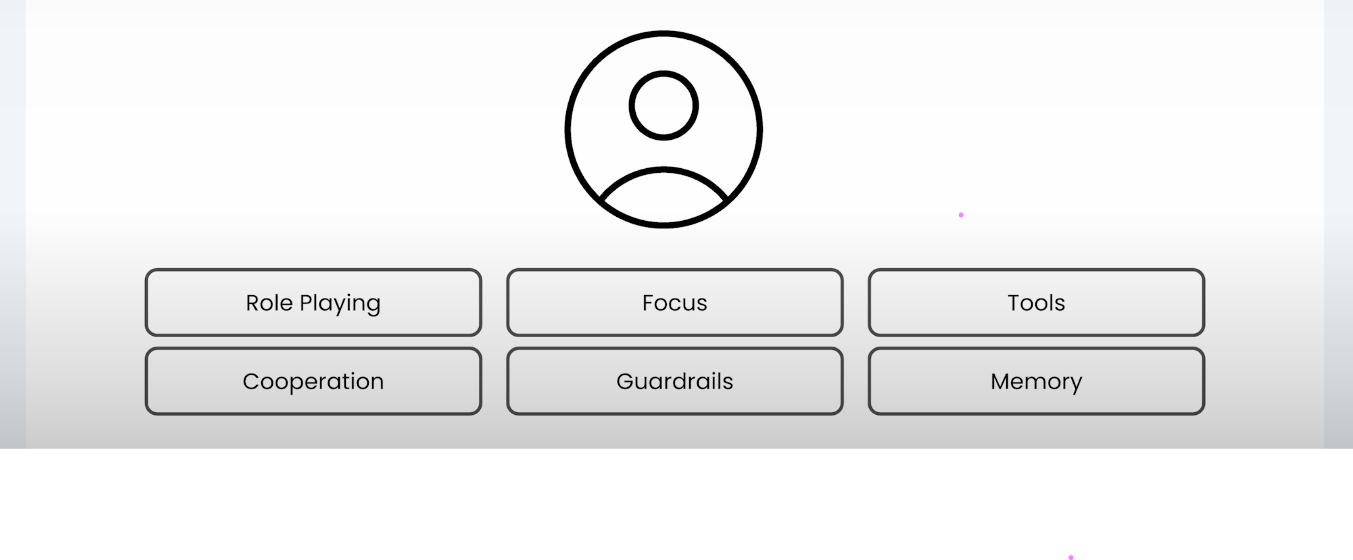

# Delgation and Tools Use

In [82]:
from crewai import Agent, Task, Crew

In [83]:
from crewai import LLM

llm = LLM(
    model="gemini/gemini-2.0-flash",
    temperature=0.7,
    api_key="YOUR_GOOGLE_API_KEY"
)

In [84]:
type(llm)


crewai.llm.LLM

### Agents

In [85]:
support_agent = Agent(
    role="Senior Support Representative",
	goal="Be the most friendly and helpful "
        "support representative in your team",
	backstory=(
		"You work at Koenig-solutions (https://www.koenig-solutions.com/) and "
        " are now working on providing "
		"support to {customer}, a super important customer "
        " for your company."
        "your support includes guiding the customers for the correct and relevant courses "
		"You need to make sure that you provide the best support!"
        "just only provide the name of courses with one line description"
		"Make sure to provide full complete answers, "
        " and make no assumptions."
	),
	allow_delegation=False,
	verbose=True,
    llm=llm
)

In [86]:
support_quality_assurance_agent = Agent(
	role="Support Quality Assurance Specialist",
	goal="Get recognition for providing the "
    "best support quality assurance in your team",
	backstory=(
		"You work at Koenig-solutions (https://www.koenig-solutions.com/) and "
        "are now working with your team "
		"on a request from {customer} ensuring that "
        "the support representative is "
		"providing the best support possible.\n"
		"You need to make sure that the support representative "
        "is providing full"
		"complete answers, and make no assumptions."
        
	),
	verbose=True,
    llm=llm
)

#### Tools

In [87]:
# !pip install crewai[tools]

In [88]:
# from crewai_tools import ScrapeWebsiteTool

# # To enable scrapping any website it finds during it's execution
# tool = ScrapeWebsiteTool()

# # Initialize the tool with the website URL, 
# # so the agent can only scrap the content of the specified website
# tool = ScrapeWebsiteTool(website_url='https://www.koenig-solutions.com/microsoft-training-certification-courses#course-list')

# # Extract the text from the site
# text = tool.run()
# print(text)

In [89]:
from crewai.tools import tool
from crewai_tools import ScrapeWebsiteTool

@tool("Koenig Course Scraper")
def courses(dummy_input: str = "") -> str:
    """Scrapes the Microsoft training and certification course list from Koenig website."""
    tool = ScrapeWebsiteTool(
        website_url="https://www.koenig-solutions.com/microsoft-training-certification-courses#course-list"
    )
    return tool.run()


In [90]:
type(courses)

crewai.tools.base_tool.Tool

#### Task

In [91]:
inquiry_resolution = Task(
    description=(
        "{customer} just reached out with a super important ask:\n"
	    "{inquiry}\n\n"
        "{person} from {customer} is the one that reached out. "
		"Make sure to use everything you know "
        "to provide the best support possible."
		"You must strive to provide a complete "
        "and accurate response to the customer's inquiry."
        "support is related to Microsoft courses"
        "just only provide the name of courses with one line description."
    ),
    expected_output=(
	    "A detailed, informative response to the "
        "customer's inquiry that addresses "
        "all aspects of their question.\n"
        "The response should include references "
        "to everything you used to find the answer, "
        "including external data or solutions. "
        "Ensure the answer is complete, "
		"leaving no questions unanswered, and maintain a helpful and friendly "
		"tone throughout."
    ),
	tools=[courses],
    agent=support_agent,
)

In [92]:
quality_assurance_review = Task(
    description=(
        "Review the response drafted by the Senior Support Representative for {customer}'s inquiry. "
        "Ensure that the answer is comprehensive, accurate, and adheres to the "
		"high-quality standards expected for customer support.\n"
        "Verify that all parts of the customer's inquiry "
        "have been addressed "
		"thoroughly, with a helpful and friendly tone.\n"
        "Check for references and sources used to "
        " find the information, "
		"ensuring the response is well-supported and "
        "leaves no questions unanswered."
    ),
    expected_output=(
        "A final, detailed, and informative response "
        "ready to be sent to the customer.\n"
        "This response should fully address the "
        "customer's inquiry, incorporating all "
		"relevant feedback and improvements.\n"
		"Don't be too formal, we are a chill and cool company "
	    "but maintain a professional and friendly tone throughout."
    ),
    agent=support_quality_assurance_agent,
)


#### Creating a crew

In [93]:
crew = Crew(
  agents=[support_agent, support_quality_assurance_agent],
  tasks=[inquiry_resolution, quality_assurance_review],
  verbose=True,
  memory=True
)

In [94]:
inputs = {
    "customer": "DeepLearningAI",
    "person": "Andrew Ng",
    "inquiry": "I need to know"
                "The courses relatd to Microsoft security operation analyst."
}
result = crew.kickoff(inputs=inputs)

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 1f944e09-b5f2-457d-a55d-e845c759fa00                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

C:\Users\esvit\anaconda3\Lib\site-packages\ipywidgets\widgets\widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

C:\Users\esvit\anaconda3\Lib\site-packages\ipywidgets\widgets\widget_output.py:112: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  self.msg_id = ip.kernel._parent_header['header']['msg_id']

2025-07-19 18:04:35,148 - 25820 - rag_storage.py-rag_storage:134 - ERROR: Error during short_term search: APIStatusError.__init__() missing 2 required keyword-only arguments: 'response' and 'body'
2025-07-19 18:04:39,292 - 25820 - rag_storage.py-rag_storage:134 - ERROR: Error during entities search: APIStatusError.__init__() missing 2 required keyword-only arguments: 'response' and 'body'


...

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new

LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

Failed to add to long term memory: Failed to convert text into a Pydantic model due to error: 
litellm.BadRequestError: VertexAIException BadRequestError - {
  "error": {
    "code": 400,
    "message": "API key expired. Please renew the API key.",
    "status": "INVALID_ARGUMENT",
    "details": [
      {
        "@type": "type.googleapis.com/google.rpc.ErrorInfo",
        "reason": "API_KEY_INVALID",
        "domain": "googleapis.com",
        "metadata": {
          "service": "generativelanguage.googleapis.com"
        }
      },
      {
        "@type": "type.googleapis.com/google.rpc.LocalizedMessage",
        "locale": "en-US",
        "message": "API key expired. Please renew the API key."
      }
    ]
  }
}

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: 5dbf7ba4-f620-47d2-a3f2-c7884a3aead3                                                                     │
│  Agent: Support Quality Assurance Specialist                                                                    │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 1f944e09-b5f2-457d-a55d-e845c759fa00                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: Hey Andrew,                                                                                      │
│                                                                                                                 │
│  So glad to help you find some awesome Microsoft courses relevant to a Security Operations Analyst! Based on    │
│  what you're looking for, here are a few that I think would be a great fit:                                     │
│                                                                                                                 │
│  *   **SC-200T00: Microsoft Security Operations Analyst** - This course is *specifically* designed for folks    │
│  stepping into or already working as a Security Operations Analyst. It dives deep into how to mitigate          │
│  threats, monitor security, and respond to incidents using Microsoft 365 Defender, Microsoft Sentinel, and      │
│  Azure Defender. If you want a course that directly aligns with the role, this is the one!                      │
│                                                                                                                 │
│      *   **Why it's relevant:** It covers the core skills and knowledge needed to effectively monitor,          │
│  analyze, and respond to security threats within a Microsoft environment.                                       │
│      *   [Link to SC-200T00 Course](https://learn.microsoft.com/en-us/training/courses/sc-200t00)               │
│  *   **AZ-500: Microsoft Azure Security Technologies** - If you're working in or planning to work in Azure      │
│  environments, this course is a must. It covers a broad range of Azure security technologies, including         │
│  implementing security controls, managing identity and access, and protecting data, applications, and networks  │
│  in the cloud.                                                                                                  │
│                                                                                                                 │
│      *   **Why it's relevant:** Security Operations Analysts often work with cloud environments, and this       │
│  course provides the knowledge to secure Azure resources effectively.                                           │
│      *   [Link to AZ-500 Course](https://learn.microsoft.com/en-us/training/courses/az-500t00)                  │
│  *   **SC-300T00: Microsoft Identity and Access Administrator** - Identity and access management is a           │
│  *critical* part of security operations. This course focuses on how to implement and manage identity and        │
│  access solutions using Azure Active Directory (Azure AD). You'll learn how to secure user access to            │
│  applications and resources, implement multi-factor authentication, and manage identity governance.             │
│                                                                                                                 │
│      *   **Why it's relevant:** Understanding identity and access management is crucial for preventing          │
│  unauthorized access and protecting sensitive data. As a Security Operations Analyst, you'll likely be          │
│  involved in managing and monitoring user access.     

In [96]:
print(result)

Hey Andrew,

So glad to help you find some awesome Microsoft courses relevant to a Security Operations Analyst! Based on what you're looking for, here are a few that I think would be a great fit:

*   **SC-200T00: Microsoft Security Operations Analyst** - This course is *specifically* designed for folks stepping into or already working as a Security Operations Analyst. It dives deep into how to mitigate threats, monitor security, and respond to incidents using Microsoft 365 Defender, Microsoft Sentinel, and Azure Defender. If you want a course that directly aligns with the role, this is the one!

    *   **Why it's relevant:** It covers the core skills and knowledge needed to effectively monitor, analyze, and respond to security threats within a Microsoft environment.
    *   [Link to SC-200T00 Course](https://learn.microsoft.com/en-us/training/courses/sc-200t00)
*   **AZ-500: Microsoft Azure Security Technologies** - If you're working in or planning to work in Azure environments, this

**Note**
- to build a good agentic syste, you shud answer to accomplish thi task what type of people I shud Hire.
    - This gives u idea about Role
    - abackstory
    - task
    - agent name and more.

# Task

In [42]:
import os
# Warning control
import warnings
warnings.filterwarnings('ignore')
from crewai import Agent, Crew, Task

In [43]:
api=os.getenv('serper_api_key')

In [44]:
from crewai import LLM

llm = LLM(
    model="gemini/gemini-2.0-flash",
    temperature=0.7,
    api_key="YOUR_GOOGLE_API_KEY"
)

In [45]:
from crewai_tools import ScrapeWebsiteTool, SerperDevTool

# Initialize the tools
search_tool = SerperDevTool(api_key=api)
scrape_tool = ScrapeWebsiteTool()

### Creating agents

In [46]:
# Agent 1: Venue Coordinator
venue_coordinator = Agent(
    role="Venue Coordinator",
    goal="Identify and book an appropriate venue "
    "based on event requirements",
    tools=[search_tool, scrape_tool],
    verbose=True,
    backstory=(
        "With a keen sense of space and "
        "understanding of event logistics, "
        "you excel at finding and securing "
        "the perfect venue that fits the event's theme, "
        "size, and budget constraints."
    ),
    llm=llm
)

In [47]:
 # Agent 2: Logistics Manager
logistics_manager = Agent(
    role='Logistics Manager',
    goal=(
        "Manage all logistics for the event "
        "including catering and equipmen"
    ),
    tools=[search_tool, scrape_tool],
    verbose=True,
    backstory=(
        "Organized and detail-oriented, "
        "you ensure that every logistical aspect of the event "
        "from catering to equipment setup "
        "is flawlessly executed to create a seamless experience."
    ),
     llm=llm
)

In [48]:
# Agent 3: Marketing and Communications Agent
marketing_communications_agent = Agent(
    role="Marketing and Communications Agent",
    goal="Effectively market the event and "
         "communicate with participants",
    tools=[search_tool, scrape_tool],
    verbose=True,
    backstory=(
        "Creative and communicative, "
        "you craft compelling messages and "
        "engage with potential attendees "
        "to maximize event exposure and participation."
    ),
    llm=llm
)

In [49]:
from pydantic import BaseModel
# Define a Pydantic model for venue details 
# (demonstrating Output as Pydantic)
class VenueDetails(BaseModel):
    name: str
    address: str
    capacity: int
    booking_status: str

## Creating Tasks
- By using `output_json`, you can specify the structure of the output you want.
- By using `output_file`, you can get your output in a file.
- By setting `human_input=True`, the task will ask for human feedback (whether you like the results or not) before finalising it.

In [50]:
venue_task = Task(
    description="Find a venue in {event_city} "
                "that meets criteria for {event_topic}.",
    expected_output="All the details of a specifically chosen"
                    "venue you found to accommodate the event.",
    human_input=True,
    output_json=VenueDetails,
    output_file="venue_details.json",  
      # Outputs the venue details as a JSON file
    agent=venue_coordinator
)

In [51]:
logistics_task = Task(
    description="Coordinate catering and "
                 "equipment for an event "
                 "with {expected_participants} participants "
                 "on {tentative_date}.",
    expected_output="Confirmation of all logistics arrangements "
                    "including catering and equipment setup.",
    human_input=True,
   
    agent=logistics_manager
)

In [52]:
marketing_task = Task(
    description="Promote the {event_topic} "
                "aiming to engage at least"
                "{expected_participants} potential attendees.",
    expected_output="Report on marketing activities "
                    "and attendee engagement formatted as markdown.",
    async_execution=True,
    output_file="marketing_report.md",  # Outputs the report as a text file
    agent=marketing_communications_agent
)

In [53]:
# Define the crew with agents and tasks
event_management_crew = Crew(
    agents=[venue_coordinator, 
            logistics_manager, 
            marketing_communications_agent],
    
    tasks=[venue_task, 
           logistics_task, 
           marketing_task],
    
    verbose=True
)

In [54]:
event_details = {
    'event_topic': "Tech Innovation Conference",
    'event_description': "A gathering of tech innovators "
                         "and industry leaders "
                         "to explore future technologies.",
    'event_city': "San Francisco",
    'tentative_date': "2024-09-15",
    'expected_participants': 500,
    'budget': 20000,
    'venue_type': "Conference Hall"
}

In [55]:
result = event_management_crew.kickoff(inputs=event_details)

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 9e083b6b-6a94-4417-8e5c-4cc332249797                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Venue Coordinator                                                                                       │
│                                                                                                                 │
│  Task: Find a venue in San Francisco that meets criteria for Tech Innovation Conference.                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

2025-07-22 14:09:16,293 - 26008 - serper_dev_tool.py-serper_dev_tool:182 - ERROR: Error making request to Serper API: 403 Client Error: Forbidden for url: https://google.serper.dev/search
Response content: b'{"message":"Unauthorized.","statusCode":403}'


╭────────────────────────────────────────────────── Tool Error ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  Tool Usage Failed                                                                                              │
│  Name: Search the internet with Serper                                                                          │
│  Error: 403 Client Error: Forbidden for url: https://google.serper.dev/search                                   │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────────── LLM Error ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ LLM Call Failed                                                                                             │
│  Error: litellm.BadRequestError: VertexAIException BadRequestError - {                                          │
│    "error": {                                                                                                   │
│      "code": 400,                                                                                               │
│      "message": "API key expired. Please renew the API key.",                                                   │
│      "status": "INVALID_ARGUMENT",                                                                              │
│      "details": [                                                                                               │
│        {                                                                                                        │
│          "@type": "type.googleapis.com/google.rpc.ErrorInfo",                                                   │
│          "reason": "API_KEY_INVALID",                                                                           │
│          "domain": "googleapis.com",                                                                            │
│          "metadata": {                                                                                          │
│            "service": "generativelanguage.googleapis.com"                                                       │
│          }                                                                                                      │
│        },                                                                                                       │
│        {                                                                                                        │
│          "@type": "type.googleapis.com/google.rpc.LocalizedMessage",                                            │
│          "locale": "en-US",                                                                                     │
│          "message": "API key expired. Please renew the API key."                                                │
│        }                                                                                                        │
│      ]                                                                                                          │
│    }                                                                                                            │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


 An unknown error occurred. Please check the details below.



╭───────────────────────────────────────────────── Task Failure ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Failed                                                                                                    │
│  Name: a7a049d5-26be-4049-9548-db755e5ab56b                                                                     │
│  Agent: Venue Coordinator                                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── Crew Failure ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Failed                                                                                          │
│  Name: crew                                                                                                     │
│  ID: 9e083b6b-6a94-4417-8e5c-4cc332249797                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output:                                                                                                  │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

BadRequestError: litellm.BadRequestError: VertexAIException BadRequestError - {
  "error": {
    "code": 400,
    "message": "API key expired. Please renew the API key.",
    "status": "INVALID_ARGUMENT",
    "details": [
      {
        "@type": "type.googleapis.com/google.rpc.ErrorInfo",
        "reason": "API_KEY_INVALID",
        "domain": "googleapis.com",
        "metadata": {
          "service": "generativelanguage.googleapis.com"
        }
      },
      {
        "@type": "type.googleapis.com/google.rpc.LocalizedMessage",
        "locale": "en-US",
        "message": "API key expired. Please renew the API key."
      }
    ]
  }
}


### Multi-agent collaboration